In [1]:
import jax
jax.default_device(jax.devices("cpu")[0])

In [2]:
import dill

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="ticks")
sns.set_theme()

In [3]:
runs = {
    "ad": "/home/bryanpu1/projects/aaai_2026/scaling_jax/results/lqr/ad-07-13-25_13_53_53-27cdb296-b335-446d-854b-45c6d631bb3d",
    "dpt": "/home/bryanpu1/projects/aaai_2026/scaling_jax/results/lqr/dpt-07-13-25_13_53_06-3bec02c7-991b-4856-8c55-df7bd806f8c0",
    "expi": "/home/bryanpu1/projects/aaai_2026/scaling_jax/results/lqr/expi-07-13-25_13_54_40-56cf44ee-c749-4c00-877b-d2bbf1c8db12",
    "stitch": "/home/bryanpu1/projects/aaai_2026/scaling_jax/results/lqr/stitch-07-13-25_13_54_26-0bc3ab6d-39de-42e2-81e8-f63522fcd90c",
    "stitch_dpt": "/home/bryanpu1/projects/aaai_2026/scaling_jax/results/lqr/stitch_predict_all-07-14-25_13_37_48-d0651047-8bf5-4b3b-bfab-83d45f188399",
}

ad             : [  -2.6394668 -706.506       -1.7467389 -707.37103     -2.115497 ]
dpt            : [-2.4122427 -6.1459703 -1.2959267 -1.9917731 -2.0849216]
expi           : [  -2.6213593  -10.03128     -1.444552  -788.4427      -1.9676859]
stitch         : [ -2.2598684  -8.430636  -22.777948   -7.958214   -2.927307 ]
stitch_dpt     : [  -2.8719604   -6.440434    -1.6220661   -1.9228891 -151.01706  ]


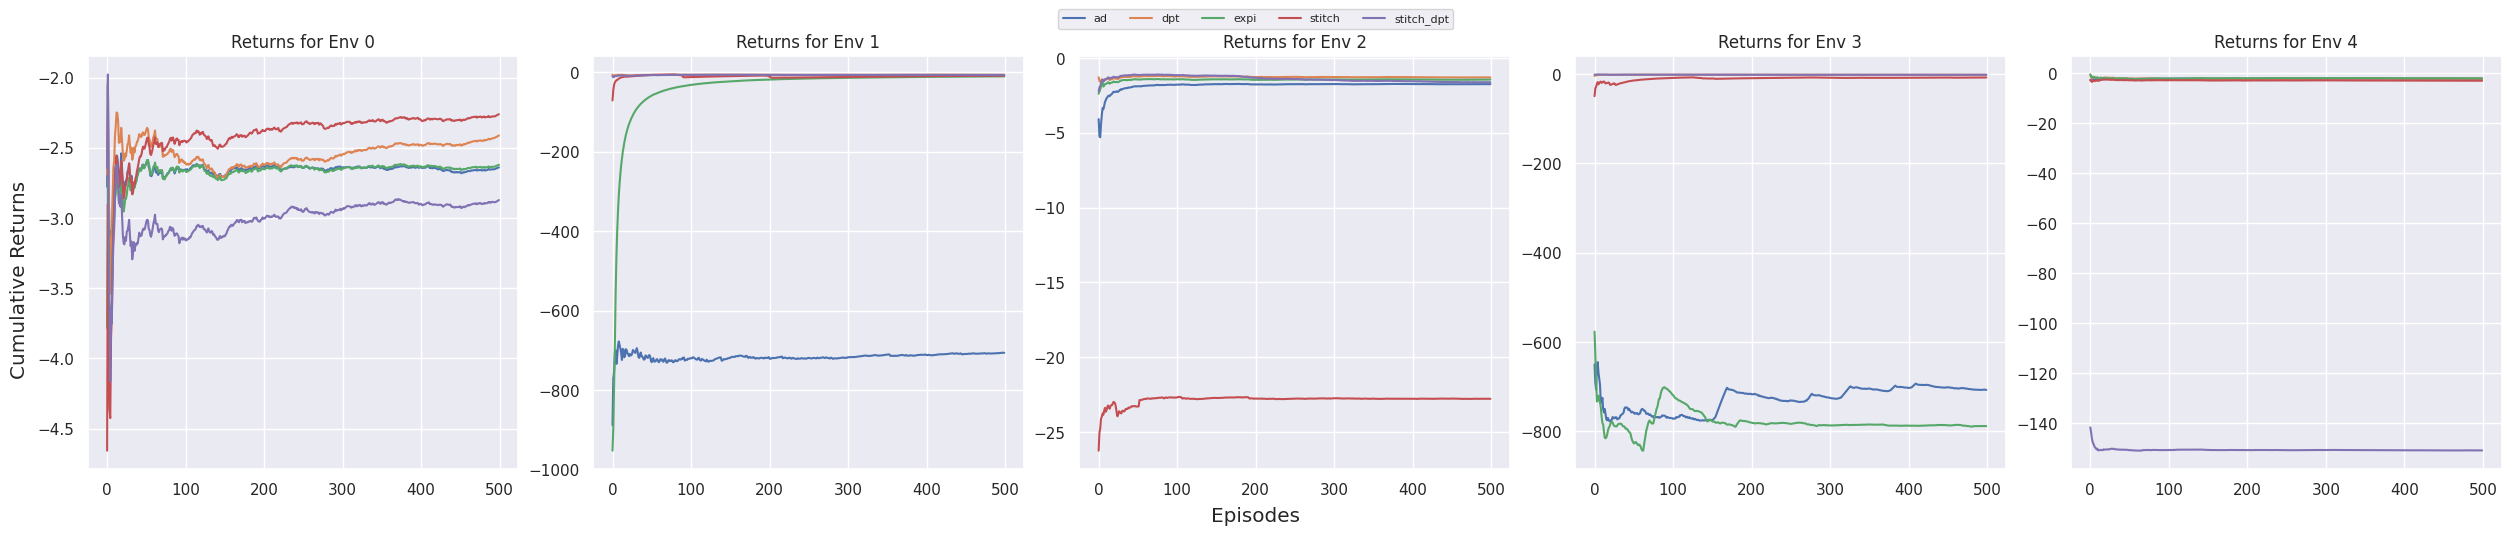

In [4]:
data = dill.load(open(f"{list(runs.values())[0]}/eval_info.dill", "rb"))
(num_envs, num_eps) = data["episode_lengths"].shape
xrange = range(num_eps)

num_cols = 5
num_rows = int(np.ceil(num_envs / 5))

fig, axes = plt.subplots(
    num_rows,
    num_cols,
    figsize=(5 * num_cols, 5 * num_rows),
    layout="constrained",
)

try:
    axes = axes.flatten()
except:
    axes = [axes]

for run_name, run in runs.items():
    data = dill.load(open(f"{run}/eval_info.dill", "rb"))
    for env_i in range(num_envs):
        axes[env_i].set_title(f"Returns for Env {env_i}")

        xrange = np.arange(len(data["episode_returns"][env_i]))
        # axes[env_i].plot(xrange, data["episode_returns"][env_i], label=run_name if env_i == 0 else "")
        axes[env_i].plot(xrange, np.cumsum(data["episode_returns"][env_i]) / (xrange + 1), label=run_name if env_i == 0 else "")
    print("{: <15}: {}".format(
        run_name,
        np.cumsum(data["episode_returns"], axis=-1)[..., -1] / num_eps
    ))

fig.supxlabel("Episodes")
fig.supylabel("Cumulative Returns")
fig.legend(
    bbox_to_anchor=(0.0, 1.0, 1.0, 0.0),
    loc="lower center",
    ncols=5,
    borderaxespad=0.0,
    frameon=True,
    fontsize="8", 
)
fig.show()

In [5]:
print(data.keys())

dict_keys(['episode_lengths', 'episode_returns', 'act_means', 'eval_config', 'env_params'])


In [6]:
data["env_params"]

{'A': Array([[[-0.68434566,  0.5853304 , -0.43922925],
         [-0.91297305,  0.7860857 , -0.7976542 ],
         [-0.9115327 ,  0.46337894,  0.49304003]],
 
        [[-0.10574841, -0.5134214 , -0.54339015],
         [ 0.8585066 , -0.7722052 ,  0.6278146 ],
         [ 0.4334837 ,  0.2961941 , -0.02877646]],
 
        [[-0.2634357 ,  0.13263302, -0.25791934],
         [ 0.1822431 ,  0.06240105, -0.02369928],
         [-0.50499374,  0.9956816 ,  0.08765974]],
 
        [[ 0.28354788, -0.4877522 , -0.7464189 ],
         [ 0.45988533,  0.86415315, -0.6959933 ],
         [ 0.44059175,  0.8486818 , -0.6612114 ]],
 
        [[ 0.22611243, -0.36557904, -0.82073694],
         [ 0.7359445 , -0.8586508 , -0.7435553 ],
         [ 0.7613464 , -0.9099014 ,  0.58044755]]], dtype=float32),
 'B': Array([[[-0.6876466 ,  0.17791903, -0.27853212],
         [-0.90492624,  0.5240171 , -0.17476994],
         [-0.22498481,  0.18883449,  0.08280946]],
 
        [[ 0.1486985 , -0.92753017,  0.963859  ],
       